# Using Meta SAM with crystal measurements

*This is the latest file, it is both the plotting_script.py and processing_script.py implemented into one fully featured notebook.*

First we have to make sure our environment has the sufficient requirements to run. The code cell below creates a conda environment that has these requirements, but git and curl need to already be installed on the machine.

Make sure to adjust *i_have_conda_installed* and *os_platform* based on if your platform and whether you have conda installed or not.

**A GPU is strongly recommended if you value your time.**

**SKIP UNTIL "USING THE NEWLY CREATED SAM ENVIRONMENT" IF YOU ARE NOT RUNNING IT FOR THE FIRST TIME**

In [1]:
if False:
    !mkdir requirements
    !mkdir outputs
    print("Cloning directory")
    !git clone https://github.com/facebookresearch/segment-anything requirements/segment-anything

    i_have_conda_installed = True
    os_platform = "windows" # windows or linux

    # if the below command returns and error, either put conda in PATH if you have it installed or set i_have_conda_installed to False
    # before running the cells below
    !conda list 

In [2]:
if False:
    if not i_have_conda_installed:
        print("Trying to install miniconda")
        if os_platform == "windows":
            !curl "https://repo.anaconda.com/miniconda/Miniconda3-latest-Windows-x86_64.exe" -o "requirements/miniconda.exe"
            !start /wait "" requirements/miniconda.exe /S
            !del requirements/miniconda.exe
        elif os_platform == "linux":
            !curl -sL "https://repo.anaconda.com/miniconda/Miniconda3-latest-Linux-x86_64.sh" > "requirements/Miniconda3.sh"
            !bash requirements/Miniconda3.sh
        else:
            print("platform unsupported")

    print("Downloading model file")
    !curl https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth -o "requirements/sam_vit_h_4b8939.pth"

    # install correct package reqs for gpu use
    print("Creating conda environment with required packages for GPU use")
    !conda create -y -n sam python==3.8 ipykernel cudatoolkit=10.2
    !conda install -y -n sam -c pytorch -c nvidia pytorch==1.9.1 torchvision==0.10.1


In [3]:
if False:
    print("Python version should be 3.8, make sure you have selected the correct python kernel")
    !python --version
    !python -m pip install opencv-python-headless supervision Pillow 
    !python -m pip install requirements/segment-anything/

## Use the newly created "sam" conda environment
Set the "sam" conda environment as the python kernel for this jupyter notebook. You can do this by clicking on the python version in the top corner and changing the python interpreter to the "sam" conda environment.

You can decide to use opencv headless or the normal package depending on how you want to display results.

**Note: You have to set the python kernel to sam for the below code to work.**

In [4]:
%load_ext autoreload
%autoreload 2

from segment_anything import SamAutomaticMaskGenerator, sam_model_registry
import torch, cv2, os, csv, re, pytesseract, math
import supervision as sv
import numpy as np
import pandas as pd

if torch.cuda.is_available():
    print("GPU is available!")
    print(f"Using {torch.cuda.get_device_name(torch.cuda.current_device())}")
else:
    print("CAUTION: GPU is not available, tensor operations will take much longer!!")

/home/zanz/.local/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


GPU is available!
Using NVIDIA GeForce GTX 1070


Below we define some useful helper functions for displaying intermediate results in a window prompt with opencv, extracting a and c dimension values and annotating/drawing all our calculations and results on the image using opencv.


### Helper function definitions

In [5]:
# Previewing whats happening, mostly for debug:
def window_img_prompt(image):
    if True:
        cv2.imshow('image',image)
        cv2.waitKey(10000)
        cv2.destroyAllWindows()

# Extracts the a and c values from a crystal mask that SAM will output       
def get_a_and_c_values(mask):
    segmentation_binary = np.array(mask["segmentation"], dtype=np.uint8) # get binary segmentation mask
    contours, _ = cv2.findContours(segmentation_binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE) # extract contours from the mask
    aprox_contours = []
    for cnt in contours: # aproximate the contours (gets rid of noisy smaller contours)
        peri = cv2.arcLength(cnt, True)
        contour = cv2.approxPolyDP(cnt,0.01*peri,True)
        aprox_contours.append(contour)
    
    maxLength = 0
    maxIndex = -1
    for index, contour_point_list in enumerate(aprox_contours):
        if len(contour_point_list) > maxLength: # Out of the aproximated contours extract the biggest one
            maxLength = len(contour_point_list)
            maxIndex = index
    if maxLength == 0 or maxLength > 10: return False # if the aproximated contour has more than 10 points or 0 points disregard it 
    # aproximated crystal contours should require aroound 6 points max
    (x_measurement,y_measurement),dist_c = cv2.minEnclosingCircle(aprox_contours[maxIndex]) # get the minimum enclosing circle (blue color) of the crystal contour
    # (it extracts the x,y values and the radius)
    x_measurement = int(x_measurement)
    y_measurement = int(y_measurement)
    M = cv2.moments(aprox_contours[maxIndex]) # using this and the below lines we get the maximum enclosed circle (inside the crystal contours) (yellow color)
    if M['m00'] != 0:
        cx = int(M['m10']/M['m00']) # center x and center y of the maximum enclosed circle
        cy = int(M['m01']/M['m00'])
    else:
        cx = x_measurement # if not possible then use the x and y of the minimum enclosing circle
        cy = y_measurement
    dist_a = cv2.pointPolygonTest(aprox_contours[maxIndex],(cx,cy),True) # calculate the a distance (maximum enclosed circle center to closest contour edge)
    # in other words dist_a is the radius of the maximum enclosed circle
    dist_a = int(dist_a)
    dist_c = int(dist_c) # convert both of them to ints because pixels can not be float
    if dist_a <= 0 or dist_c <= 0: # if either of them are negative (not found) skip this crystal
        return False
    ret_dict = { # return all the relevant values
        "dist_a":dist_a,
        "dist_c":dist_c,
        "center_x":x_measurement,
        "center_y":y_measurement,
        "aprox_contours":aprox_contours,
        "max_contour": aprox_contours[maxIndex],
        "center_x_cont": cx,
        "center_y_cont": cy,
    }
    return ret_dict

# Draws on the image so the user can see whats actually happening, has a mode to display measurements in red text or not
def annotate_image(image,masks, scale_factor,visualize_contours=False, visualize_measurements=False): # this will draw everything on the image so we can see what is happening
    mask_annotator = sv.MaskAnnotator()
    if len(masks) == 0:
        print("You filtered all the masks >:(")
        return image
    detections = sv.Detections.from_sam(masks)
    annotated_image = mask_annotator.annotate(image, detections) # draws the colored sam model segmentations on each crystal
    if visualize_contours: # our draw function for the measurements
        for mask in masks:
            x_val = int(mask["bbox"][0])
            y_val = int(mask["bbox"][1])
            if x_val + 5 >= annotated_image.shape[1] or y_val + 10 >= annotated_image.shape[0]: # if object is out of image bounds skip it
                continue
            
            measurement_dict = get_a_and_c_values(mask) # see function above
            if not measurement_dict: continue # if not a good crystal skip this
            
            dist_a = measurement_dict["dist_a"]
            dist_c = measurement_dict["dist_c"]
            center_x = measurement_dict["center_x"]
            center_y = measurement_dict["center_y"]
            aprox_contours = measurement_dict["aprox_contours"]
            cx = measurement_dict["center_x_cont"]
            cy = measurement_dict["center_y_cont"]
            
            annotated_image = cv2.drawContours(annotated_image, aprox_contours, -1, (0,255,0), 3)
            annotated_image = cv2.circle(annotated_image, (center_x,center_y), radius=3, color=(255, 0, 0), thickness=-1) # draw blue circle and blue dot
            annotated_image = cv2.circle(annotated_image, (center_x,center_y), radius=dist_c, color=(255,0,0), thickness=1)
            
            annotated_image = cv2.circle(annotated_image, (cx,cy), radius=3, color=(0, 255, 255), thickness=-1) # draw yellow circle and yellow dot
            annotated_image = cv2.circle(annotated_image, (cx,cy), radius=dist_a, color=(0,255,255), thickness=1)

            if visualize_measurements:
                text = f"A:{dist_a*2*scale_factor:.2f}|C:{dist_c*2*scale_factor:.2f}|area:{mask['area']*scale_factor:.2f}"
                font = cv2.FONT_HERSHEY_SIMPLEX
                font_scale = 0.45
                font_thickness = 1
                x,y  = x_val + 5, y_val + 10
                text_size, _ = cv2.getTextSize(text, font, font_scale, font_thickness)
                text_w, text_h = text_size
                text_color_bg=(0, 0, 0)
                text_color = (0, 0, 255)
                #annotated_image = cv2.rectangle(annotated_image, (x_val,y_val), (x + text_w, y + text_h), text_color_bg, -1)
                annotated_image = cv2.putText(annotated_image, text,
                                    (x,y), font, fontScale=font_scale, color=text_color, thickness=font_thickness, lineType=cv2.LINE_AA)
            # draw the red text with the A, C and area measurements
    return annotated_image

# Extracts text using pytesseract and image processing, when it returns -404 it means that the value parsed was invalid
def parse_ocr_scale_info(image_path):
    return_dict = {'nm_value': -404, 'nm_in_pixels': -404, 'pixel_in_nms': -404} 
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    #window_img_prompt(image)
    # Threshold the image to get a binary image
    _, image = cv2.threshold(image, 128, 255, cv2.THRESH_BINARY)
    
    #window_img_prompt(image)
    x, y, w, h = (0,1024,338,32)
    line_region = image[y:y+h, x:x+w]
    #window_img_prompt(line_region)
    x, y, w, h = (0,1055,338,32)
    text_region = image[y:y+h, x:x+w]
    #window_img_prompt(text_region)
    
    
    first_white_x,last_white_x = find_first_and_last_pix(text_region,axis = 1)
    
    subregion = text_region[7:24,first_white_x-4:last_white_x-30] # -30 removes um unit notation
    #window_img_prompt(subregion)
    subregion = cv2.copyMakeBorder(subregion, 40, 40, 40, 40, cv2.BORDER_CONSTANT)
    #window_img_prompt(subregion)
    subregion = cv2.bitwise_not(subregion)
    #window_img_prompt(subregion)
    subregion = cv2.resize(subregion, (540, 340), 
               interpolation = cv2.INTER_LINEAR)
    kernel = np.ones((5, 5), np.uint8) 
  
    subregion = cv2.erode(subregion, kernel, iterations=1) 
    #window_img_prompt(subregion)
    
    valid = False
    output_numbers = []
    psm_modes = [8,9,13]
    for psm_mode in psm_modes:
        psm_val = str(psm_mode)
        text = pytesseract.image_to_string(subregion,config=f'outputbase digits --psm {psm_mode} -c tessedit_char_whitelist=0123456789')
        numbers = re.findall(r'\d+', text)
        if len(numbers)> 0:
            valid = True
            #print("Valid numbers found!")
            output_numbers = numbers
            break
        
    if not valid:
        print(f"Not valid text {text} containing {numbers} with psm mode {psm_val} \n")
        #window_img_prompt(subregion)
        return return_dict
    
    first_white_x,last_white_x = find_first_and_last_pix(line_region,axis = 1)
    return_dict["nm_value"] = int(max(output_numbers, key=len))
    return_dict["nm_in_pixels"] = last_white_x-first_white_x
    return_dict["pixel_in_nms"] = return_dict["nm_value"] / return_dict["nm_in_pixels"] 
    return return_dict

# Finds the borders of the scale text in the bottom left so it can be easily and accurately extracted for OCR with pytesseract
def find_first_and_last_pix(img,axis):
    first_white_x = -1
    last_white_x = -1
    for ax in range(img.shape[axis]):
        if img[:,ax].any():
            if first_white_x == -1:
                first_white_x = ax
            elif first_white_x != -1:
                last_white_x = ax
    return first_white_x,last_white_x
    
    

The main loop for reading our images and generating a csv dataset. 

**Make sure to adjust the folder and file paths here to point to where these files are on your system. And additionally any parameters you want to test**

### Calculating crystals, extracting nm scale automatically with image processing, and applying post processing filtering

In [6]:
device_cuda = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f"Device used: {device_cuda}")

#model_name = "sam_hq_vit_h.pth"
model_name = "sam_vit_h_4b8939.pth"
sam = sam_model_registry["vit_h"](checkpoint=f"/home/zanz/ml_stuff/ml_playground/data/facebook_sam/sam_checkpoints/{model_name}")
sam.to(device=device_cuda)
torch.cuda.empty_cache()

root_image_folder = "/home/zanz/ml_stuff/ml_playground/data/facebook_sam/science_data/images/all_big_run_images/"
print(f"Working on: \n \n {root_image_folder} \n \n")
file_list = sorted(os.listdir(root_image_folder))
file_list.reverse()
# defaults:
# points_per_side = 32 
# pred_iou_thresh: float = 0.88,
# stability_score_thresh: float = 0.95,
# box_nms_thresh: float = 0.7,
# crop_n_layers: int = 0,
# crop_nms_thresh: float = 0.7,
# crop_overlap_ratio: float = 512 / 1500,
stability_score_thresh = 0.95 # default, ignore
crop_overlap_ratio = 512 / 1500 # default, ignore
points_per_side = 32 # default, ignore


iou_tresh = 0.95 # 97 before # (0.88 to 0.97 likely good)
crop_n_lay = 1 
# 0 is very fast, but can benefit from finding more objects, 1 is better at this but slower
# 2 is a tiny bit more accurate than 1 but because of the computational costs (more than 4x slower) we use 1
# 3 takes extremely long for no real benefit

#step_list = np.linspace(1,5)
step_list = [1]
print(step_list)

if True: # uncomment these if you want to use it

    for step_val in step_list:
        #points_per_side = step_val
        print(f"Current step value: {step_val}")
        mask_generator = SamAutomaticMaskGenerator(
            sam,
            pred_iou_thresh=iou_tresh,
            crop_n_layers=crop_n_lay,
            crop_overlap_ratio=crop_overlap_ratio,
            points_per_side=points_per_side
        )

        # set the image you want to test here, if you want to test it on a specific image, otherwise by default it will run trough the folder
        image_range_start = 0 # 36
        image_range_end = len(file_list) # 37

        csv_output = []
        for index, filename in enumerate(file_list[image_range_start:image_range_end]):
            print(f"\n{index}/{image_range_end} Done")
            if not filename.endswith('.tiff'): continue 
            
            image_path = f"{root_image_folder}/{filename}"
            image_uncropped = cv2.imread(image_path)
            
            scale_dict = parse_ocr_scale_info(image_path)
            print(scale_dict)
            
            img_width = 1024
            img_height = 1024
            print(f"shape before: {image_uncropped.shape}")
            if image_uncropped.shape[1] > img_height or image_uncropped.shape[2] > img_width:
                image_rgb = image_uncropped[240:1524, 300:1524]  # custom crop sizes
            else:
                image_rgb = image_uncropped[0:img_width, 0:img_height] 
            # idk why, but for some reason the image now becomes 1024 x 1024 
            #instead of the original 1088 x 1024, but its good since the extra pixels are the microscope UI at the bottom
            
            print(f"shape: {image_rgb.shape}, np amax:{np.amax(image_rgb)}, np amin:{np.amin(image_rgb)}")
            
            masks = mask_generator.generate(image_rgb) # generates the masks (calls the model)
            filter_count = 0
            print(f"filename: {filename}")
            #annotated_image = annotate_image(image_rgb,masks,visualize_contours=True)
            #window_img_prompt(annotated_image)
            
            # Post processing below
            filtered_masks = []
            stats_area_list = []
            for mask in masks:
                bbox_width = mask["bbox"][2]
                bbox_height = mask["bbox"][3]
                area = mask["area"]
                segmentation_binary = mask["segmentation"]
                if bbox_height <= bbox_width: # gets the a and b values of the bounding box of the crystal
                    a_rect = bbox_height
                    b_rect = bbox_width
                else:
                    b_rect = bbox_height
                    a_rect = bbox_width
                # We need to calculate the ratio of b/a to filter out masks where b is much too long
                #     |-------------|
                #   a |< (crystal) >| good crystal
                #     |-------------|
                #            b
                # (the longest of the two sides will always become b because of the above check)
                #     |----------------------------------------------|
                #   a |<                   (crystal)                >| bad crystal
                #     |----------------------------------------------|
                #                              b   
                if a_rect == 0:
                    filter_count += 1
                    continue
                else:
                    b_ratio = b_rect / a_rect # good examples are 4/1, 3/1, 2/1, 1/1 
                
                if area < 1000 or b_ratio > 4: # remove all crystals with an area smaller than 1000 or where the b_ratio is more than 4
                    filter_count += 1
                    continue
                
                
                measurement_dict = get_a_and_c_values(mask)
                if not measurement_dict: 
                    filter_count += 1
                    continue
                
                dist_a = measurement_dict["dist_a"]
                dist_c = measurement_dict["dist_c"]
                center_x = measurement_dict["center_x"]
                center_y = measurement_dict["center_y"]
                center_x_cont = measurement_dict["center_x_cont"]
                center_y_cont = measurement_dict["center_y_cont"]
                aprox_contours = measurement_dict["aprox_contours"]
                max_contour = measurement_dict["max_contour"]
                
                # filtering based on a and c lengths in proportion, was too strict so it is not used
                #if dist_a * 2 > dist_c or dist_a * 3 < dist_c:
                #    filter_count += 1
                #    continue
                
                # if blue and yellow center dots are too far away the object is very likely not a symetrical crystal; disregard it.
                # this was too strict so in the end i decided not to use it.
                points_inner_circ = [center_x,center_y]
                points_contour_circ = [center_x_cont,center_y_cont]
                distance = math.dist(points_inner_circ, points_contour_circ) 
                length_diff = abs(dist_a-dist_c)
                if distance > dist_a*0.10 or length_diff < 0.3:
                    filter_count += 1
                    continue
                
                stats_area_list.append(mask["area"])
                filtered_masks.append(mask)
            
            if len(filtered_masks) == 0: continue
            #annotated_image = annotate_image(image_rgb,filtered_masks,visualize_contours=True)
            #window_img_prompt(annotated_image)
                
            stats_area_array = np.array(stats_area_list)
            
            area_median = np.median(stats_area_array)
            area_mad = np.median(np.absolute(stats_area_array - np.median(stats_area_array)))
            
            area_mean = np.mean(stats_area_array)
            area_std = np.std(stats_area_list)
            
            write_file_name = f"outputs/{filename}_st{stability_score_thresh}_it{iou_tresh}_l{crop_n_lay}_pps{points_per_side}_over{crop_overlap_ratio:.2f}"
            stat_filtered_masks = []
            for mask in filtered_masks:
                area = mask["area"]
                if area < area_median-1*area_mad or area > area_median+1*area_mad:
                    # if the area of a mask doesnt fall within 1 median absolute deviation of the filtered means we remove them
                    filter_count += 1
                    continue
                
                measurement_dict = get_a_and_c_values(mask)
                if not measurement_dict: 
                    filter_count += 1
                    continue
                
                dist_a = measurement_dict["dist_a"]
                dist_c = measurement_dict["dist_c"]
                center_x = measurement_dict["center_x"]
                center_y = measurement_dict["center_y"]
                center_x_cont = measurement_dict["center_x_cont"]
                center_y_cont = measurement_dict["center_y_cont"]
                aprox_contours = measurement_dict["aprox_contours"]
                max_contour = measurement_dict["max_contour"]
                
                stat_filtered_masks.append(mask)
                csv_output.append([
                    write_file_name, # see header below
                    dist_a*2*scale_dict["pixel_in_nms"],
                    dist_c*2*scale_dict["pixel_in_nms"],
                    dist_a*2,
                    dist_c*2,
                    center_x,
                    center_y,
                    center_x_cont,
                    center_y_cont,
                    area,
                    scale_dict["pixel_in_nms"],
                    scale_dict["nm_in_pixels"],
                    scale_dict["nm_value"]
                ])

            print(f"Filtered {filter_count} masks")
            if len(stat_filtered_masks) == 0: continue
            #print(write_file_name)
            #temp_df = pd.DataFrame(csv_output, columns =["filename",
            #                                             "dist_a_nm",
            #                                             "dist_c_nm",
            #                                             "dist_a_pix",
            #                                             "dist_c_pix",
            #                                             "center_x_outer",
            #                                             "center_y_outer",
            #                                             "center_x_inner",
            #                                             "center_y_inner",
            #                                             "area_pix",
            #                                             "scale_pixel_in_nms",
            #                                             "scale_nm_in_pixels",
            #                                             "scale_nm_value"])
            #mean_df = temp_df[temp_df["filename"] == write_file_name].mean()
            #std_df = temp_df[temp_df["filename"] == write_file_name].std()
            #count_df = len(temp_df[temp_df["filename"] == write_file_name])
            
            #print(f"Count: {count_df} Mean: {mean_df} Standard deviation: {std_df}")
            annotated_image = annotate_image(image_rgb,stat_filtered_masks,scale_dict["pixel_in_nms"],visualize_contours=True)
            annotated_image_measurements = annotate_image(image_rgb,stat_filtered_masks,scale_dict["pixel_in_nms"],visualize_contours=True,visualize_measurements=True)
            #window_img_prompt(annotated_image)
            
            cv2.imwrite(f"{write_file_name}.jpg",annotated_image,[cv2.IMWRITE_JPEG_QUALITY, 100])
            cv2.imwrite(f"{write_file_name}_measurements.jpg",annotated_image_measurements,[cv2.IMWRITE_JPEG_QUALITY, 100])
            
            
            #break # only do one image from the images for now
        
        # creates a .csv dataset for further analysis and plotting
        with open(f'outputs/dataset_st{stability_score_thresh}_it{iou_tresh}_l{crop_n_lay}_over{crop_overlap_ratio:.2f}.csv', 'a', newline='\n') as csvfile:
            datawriter = csv.writer(csvfile, delimiter='|', quoting=csv.QUOTE_MINIMAL)
            datawriter.writerow(["filename",
                                 "dist_a_nm",
                                 "dist_c_nm",
                                 "dist_a_pix",
                                 "dist_c_pix",
                                 "center_x_outer",
                                 "center_y_outer",
                                 "center_x_inner",
                                 "center_y_inner",
                                 "area_pix",
                                 "scale_pixel_in_nms",
                                 "scale_nm_in_pixels",
                                 "scale_nm_value"]) # header
            for row in csv_output:
                datawriter.writerow(row)

Device used: cuda:0
Working on: 
 
 /home/zanz/ml_stuff/ml_playground/data/facebook_sam/science_data/images/all_big_run_images/ 
 

[1]
Current step value: 1

0/628 Done
{'nm_value': 10, 'nm_in_pixels': 177, 'pixel_in_nms': 0.05649717514124294}
shape before: (1088, 1024, 3)
shape: (1024, 1024, 3), np amax:255, np amin:0
filename: yAl2O3 4h TPA=0_0007.tiff
Filtered 110 masks

1/628 Done
{'nm_value': 20, 'nm_in_pixels': 238, 'pixel_in_nms': 0.08403361344537816}
shape before: (1088, 1024, 3)
shape: (1024, 1024, 3), np amax:255, np amin:0
filename: yAl2O3 4h TPA=0_0006.tiff
Filtered 86 masks

2/628 Done
{'nm_value': 30, 'nm_in_pixels': 322, 'pixel_in_nms': 0.09316770186335403}
shape before: (1088, 1024, 3)
shape: (1024, 1024, 3), np amax:255, np amin:0
filename: yAl2O3 4h TPA=0_0005.tiff

3/628 Done
{'nm_value': 30, 'nm_in_pixels': 265, 'pixel_in_nms': 0.11320754716981132}
shape before: (1088, 1024, 3)
shape: (1024, 1024, 3), np amax:255, np amin:0
filename: yAl2O3 4h TPA=0_0004.tiff
Filte

# Plots using the automatically extracted scale from the image

Plotting all of the data and saving it as hexbins (so you can see what ranges of measurements are most common)

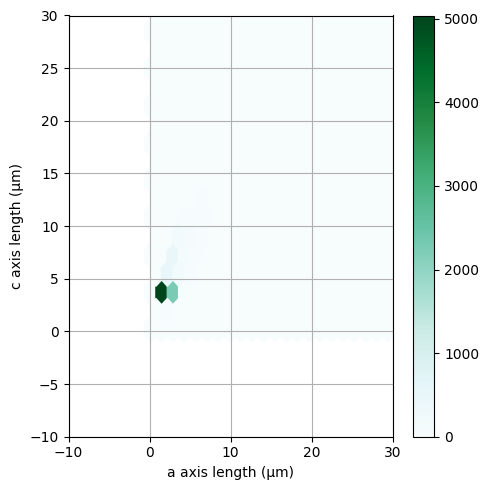

In [43]:
import matplotlib.pyplot as plt
import pandas as pd


plot_dframe_raw = pd.read_csv("outputs/dataset_st0.95_it0.95_l1_over0.34.csv",delimiter="|",header=0)
#print(plot_dframe_main)
#,xlim=(20,60),ylim=(25,100)
plot_dframe_main = plot_dframe_raw.copy()
plot_dframe_main = plot_dframe_main[(plot_dframe_main["dist_a_nm"] < 100.0) & (plot_dframe_main["dist_c_nm"] < 100.0) & (plot_dframe_main["dist_a_nm"] > 0.0) & (plot_dframe_main["dist_c_nm"] > 0.0)]
plot_dframe_main.plot(x="dist_a_nm",y="dist_c_nm",kind='hexbin',xlim=(-10,30),ylim=(-10,30),grid=True,gridsize=50,xlabel="a axis length (μm)",ylabel="c axis length (μm)",figsize=(5,5))
plt.tight_layout()
plt.savefig('outputs/Plot_hexbin_all.png')
plt.show()

Plotting 2 histogram of readings of 2 images (with calculated scale)

Showing outputs/Glass 2h TPA=0_0009.tiff_st0.95_it0.95_l1_pps32_over0.34


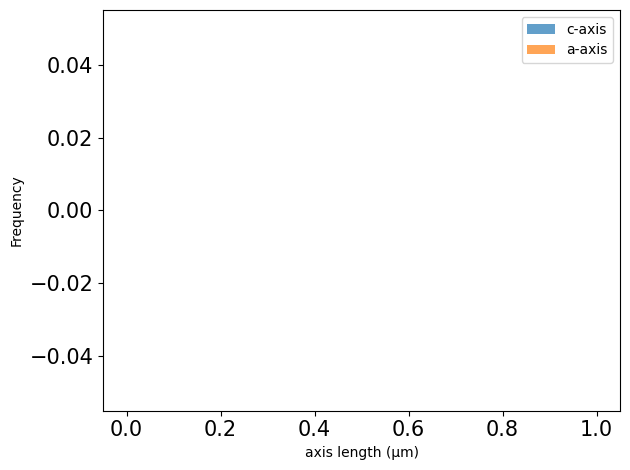

[]
Showing outputs/Glass 5h TPA=0.05_0005.tiff_st0.95_it0.95_l1_pps32_over0.34


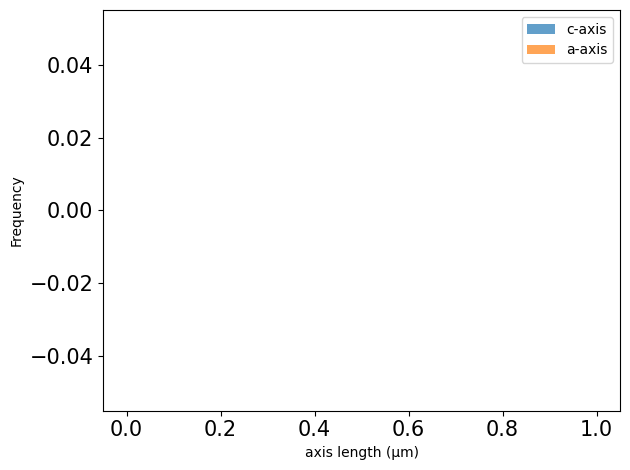

[]


In [44]:
image1 = "outputs/Glass 2h TPA=0_0009.tiff_st0.95_it0.95_l1_pps32_over0.34"
image2 = "outputs/Glass 5h TPA=0.05_0005.tiff_st0.95_it0.95_l1_pps32_over0.34"
base_name1 = image1.split("/")[1].split(".tiff")[0]
base_name2 = image2.split("/")[1].split(".tiff")[0]


dframe_image1 = plot_dframe_main[plot_dframe_main["filename"]==image1].copy(deep=True)
dframe_image2 = plot_dframe_main[plot_dframe_main["filename"]==image2].copy(deep=True)

print(f"Showing {image1}")
dframe_image1[['dist_c_nm','dist_a_nm']].sort_index().plot(kind='hist',alpha=0.7,bins=20,xlabel="axis length (μm)")
dframe_image1.sort_values(by='dist_c_nm')
#plt.xlim(2,8)
#plt.yticks([0,40,80,120])
plt.xticks(rotation=0,size=15)
plt.yticks(size=15)
plt.legend(["c-axis", "a-axis"])
plt.tight_layout()
plt.savefig(f'outputs/barPlot_{base_name1}.png')
plt.show()
print(list(dframe_image1['dist_c_nm']))


print(f"Showing {image2}")
dframe_image2[['dist_c_nm','dist_a_nm']].sort_index().plot(kind='hist',alpha=0.7,bins=20,xlabel="axis length (μm)")
dframe_image2.sort_values(by='dist_c_nm')
#plt.xlim(2,8)
#plt.yticks([1,3,5,7])
plt.xticks(rotation=0,size=15)
plt.yticks(size=15)
plt.legend(["c-axis", "a-axis"])
plt.tight_layout()
plt.savefig(f'outputs/barPlot_{base_name2}.png')
plt.show()
print(list(dframe_image2['dist_c_nm']))

 Plotting 2 histograms for all the images and objects in the Glass 2h TPA=0 and 5h TPA=0.05 conditions (with automatically calculated scale)

0
0
nan
Series([], Name: dist_c_nm, dtype: float64)
images Glass 2h TPA=0_ with 0 hits


/home/zanz/.local/lib/python3.8/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/zanz/.local/lib/python3.8/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


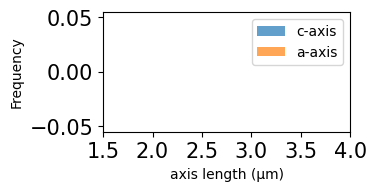

/home/zanz/.local/lib/python3.8/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/zanz/.local/lib/python3.8/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


nan
Series([], Name: dist_c_nm, dtype: float64)
images Glass 5h TPA=0.05 with 0 hits


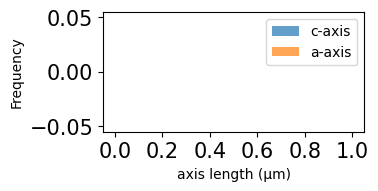

In [9]:
plot_dframe_main2 = plot_dframe_main.copy(deep=True)

images1 = "Glass 2h TPA=0_"
images2 = "Glass 5h TPA=0.05"


image1_df = plot_dframe_main2[plot_dframe_main2['filename'].str.contains(images1)]

image2_df = plot_dframe_main2[plot_dframe_main2['filename'].str.contains(images2)]
print(len(image1_df["filename"]))
print(len(image2_df["filename"]))

print(np.median(image1_df['dist_c_nm']))
print(image1_df['dist_c_nm'])

print(f"images {images1} with {len(image1_df['dist_c_nm'])} hits")
image1_df[['dist_c_nm','dist_a_nm']].plot(kind='hist',alpha=0.7,density=False,bins=100,xlabel="axis length (μm)",figsize=(4,2))
#image1_df.sort_values(by='dist_c_nm')
plt.xlim(1.5,4)
#plt.yticks([0,40,80,120])
plt.xticks(rotation=0,size=15)
plt.yticks(size=15)
plt.tight_layout()
plt.legend(["c-axis", "a-axis"])
plt.savefig(f'outputs/barPlot_multiple_{images1}.png')
plt.show()


print(np.median(image2_df['dist_c_nm']))
print(image2_df['dist_c_nm'])

print(f"images {images2} with {len(image2_df['dist_c_nm'])} hits")
image2_df[['dist_c_nm','dist_a_nm']].plot(kind='hist',alpha=0.7,bins=20,density=False,xlabel="axis length (μm)",figsize=(4,2))
#image2_df.sort_values(by='dist_c_nm')
#plt.xlim(2,8)
#plt.yticks([1,3,5,7])
plt.xticks(rotation=0,size=15)
plt.yticks(size=15)
plt.tight_layout()
plt.legend(["c-axis", "a-axis"])
plt.savefig(f'outputs/barPlot_multiple_{images2}.png')
plt.show()

Scatter plot (all average values per condition) (automatically calculated scale)

In [10]:
plot_dframe_copy = plot_dframe_main.copy(deep=True)

#print(plot_dframe_copy)

dicting = []
for image_names in plot_dframe_copy["filename"]:
    setting_name = image_names.split("/")[1].split(".tiff")[0]
    if setting_name not in dicting:
        dicting.append(setting_name)

name_dict =  {}
for image_names in plot_dframe_copy["filename"]:
    setting_name = image_names.split("/")[1].split("_")[0]
    setting_name += "_"

    if setting_name not in name_dict:
        name_dict[setting_name] = True

print(name_dict)
df_dict = {
    "condition_setting": [],
    "time_h": [],
    "a_nm": [],
    "c_nm": [],
    "a_pixel": [],
    "c_pixel": []
}

averages_condition = {}

for key, value in name_dict.items():
    mask = plot_dframe_copy['filename'].str.contains(key)
    true_vals = sum(mask)
    setting_name_list = [key] * true_vals
    h_setting  = [int(key.split(" ")[1].replace("h",""))] * true_vals
    df_dict["condition_setting"].extend(setting_name_list)
    df_dict["time_h"].extend(h_setting)
    df_dict["a_nm"].extend(plot_dframe_copy.loc[mask,"dist_c_nm"])
    df_dict["c_nm"].extend(plot_dframe_copy.loc[mask,"dist_a_nm"])
    df_dict["a_pixel"].extend(plot_dframe_copy.loc[mask,"dist_c_pix"])
    df_dict["c_pixel"].extend(plot_dframe_copy.loc[mask,"dist_a_pix"])
    
    averages_condition[key] = {
        "time": int(key.split(" ")[1].replace("h","")),
        "a_mean": plot_dframe_copy.loc[mask,"dist_c_nm"].mean(),
        "c_mean": plot_dframe_copy.loc[mask,"dist_a_nm"].mean(),
        "a_median": plot_dframe_copy.loc[mask,"dist_c_nm"].median(),
        "c_median": plot_dframe_copy.loc[mask,"dist_a_nm"].median(),
        "a_std": plot_dframe_copy.loc[mask,"dist_c_nm"].std(),
        "c_std": plot_dframe_copy.loc[mask,"dist_a_nm"].std(),
    }
    #print(max(df_dict["a_nm"]))
    #print(max(df_dict["c_nm"]))
    #print(f"Mask length: {len(mask)}, vals: {true_vals}")
    #print(f"a length: {len(plot_dframe_main.loc[mask,'dist_a'])} c length: {len(plot_dframe_main.loc[mask,'dist_c'])}")
    assert true_vals == len(h_setting) == len(setting_name_list) == len(plot_dframe_copy.loc[mask,"dist_c_nm"]) == len(plot_dframe_copy.loc[mask,"dist_a_nm"])
    
print(df_dict.keys())

{'yAl2O3 4h TPA=0_': True, 'yAl2O3 4h TPA=0.2_': True, 'yAl2O3 4h TPA=0.075_': True, 'yAl2O3 4h TPA=0.05_': True, 'yAl2O3 4h TPA=0.025_': True, 'yAl2O3 24h NH4=0 NaF=4_': True, 'yAl2O3 24h NH4=0 NaF=1.5_': True, 'yAl2O3 24h NH4=0 NaF=0.5_': True, 'Silicon, TPASi= 0.1_': True, 'Silicon, TPASi= 0.05_': True, 'Silicon, TPASI= 0.05_': True, 'Silicon NH4=0 NaF = 4_': True, 'Silicon NH4=0 NaF = 1.5_': True, 'Silicon NH4=0 NaF = 0.5_': True, 'Silicon 5h, TPA = 0_': True, 'Silicon 5h, TPA = 0.2_': True, 'Silicon 5h, TPA = 0.05_': True, 'Silicon 4h_': True, 'Silicon 4h NaF = 1_': True, 'Silicon 4h NaF = 1.5_': True, 'Silicon 4h NaF = 0.5_': True, 'Silicon 2h, TPA = 0_': True, 'Silicon 2h, TPA = 0.2_': True, 'Silicon 2h, TPA = 0.05_': True, 'Silicon 2h NaF = 1_': True, 'Silicon 2h NaF = 1.5_': True, 'Silicon 2h NaF = 0.5_': True, 'Silicon 20h, TPA = 0_': True, 'Silicon 20h, TPA = 0.2_': True, 'Silicon 20h, TPA = 0.05_': True, 'Silicon 20h NaF = 1_': True, 'Silicon 20h NaF = 1.5_': True, 'Silicon

ValueError: invalid literal for int() with base 10: 'TPASi='

{'Glass 5h TPA=0_': {'time': 5, 'a_mean': 3.3123474821958614, 'c_mean': 2.059262992740438, 'a_median': 3.3121019108280256, 'c_median': 2.046511627906977, 'a_std': 0.042727574812544473, 'c_std': 0.06874267049991986}, 'Glass 5h TPA=0.2_': {'time': 5, 'a_mean': 3.747593421581409, 'c_mean': 2.282881267979956, 'a_median': 3.7288135593220337, 'c_median': 2.2988505747126435, 'a_std': 0.3431237357744879, 'c_std': 0.2625908731047273}, 'Glass 5h TPA=0.05_': {'time': 5, 'a_mean': 6.526587281072107, 'c_mean': 2.5671417164980728, 'a_median': 6.590038314176245, 'c_median': 2.6053639846743293, 'a_std': 0.12746763755384535, 'c_std': 0.1380265625633876}, 'Glass 2h TPA=0_': {'time': 2, 'a_mean': 3.2751970147852005, 'c_mean': 2.035424195439732, 'a_median': 3.257328990228013, 'c_median': 2.046511627906977, 'a_std': 0.03708732333184576, 'c_std': 0.07544924220617354}, 'Glass 2h TPA=0.2_': {'time': 2, 'a_mean': 3.689172183713332, 'c_mean': 2.225874516718236, 'a_median': 3.725490196078432, 'c_median': 2.25490

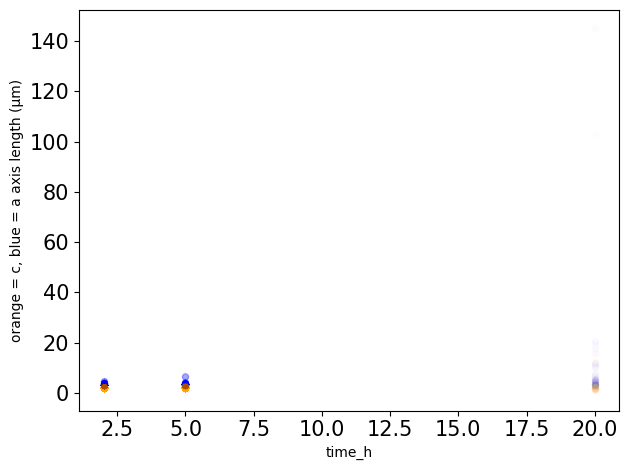

In [ ]:
global_scatterplot_dframe = pd.DataFrame(df_dict)
# Display the resulting DataFrame
print(averages_condition)
ax1 = global_scatterplot_dframe.plot.scatter(x='time_h',y=['a_nm'],c='blue',marker='o',alpha=0.01)
global_scatterplot_dframe.plot.scatter(x='time_h',y=['c_nm'],c='orange',alpha=0.01,ylabel="orange = c, blue = a axis length (μm)", ax=ax1)

#global_scatterplot_dframe.to_csv('global_values.csv',index=False)  
#image2_df.sort_values(by='dist_c_nm')
#plt.xlim(2,8)
#plt.yticks([1,3,5,7])
plt.xticks(rotation=0,size=15)
plt.yticks(size=15)
plt.tight_layout()
plt.savefig(f'outputs/time_scatterplot_all.png')
plt.show()

                     time     a_mean     c_mean   a_median   c_median   
Glass 5h TPA=0_       5.0   3.312347   2.059263   3.312102   2.046512  \
Glass 5h TPA=0.2_     5.0   3.747593   2.282881   3.728814   2.298851   
Glass 5h TPA=0.05_    5.0   6.526587   2.567142   6.590038   2.605364   
Glass 2h TPA=0_       2.0   3.275197   2.035424   3.257329   2.046512   
Glass 2h TPA=0.2_     2.0   3.689172   2.225875   3.725490   2.254902   
Glass 2h TPA=0.05_    2.0   4.017404   2.213100   3.892462   2.248521   
Glass 20h TPA=0_     20.0  27.624102  18.961704  16.598639  11.428571   
Glass 20h TPA=0.2_   20.0   5.668564   2.504003   4.366197   1.751412   
Glass 20h TPA=0.05_  20.0   4.212026   2.454476   4.033613   2.046512   

                         a_std      c_std  
Glass 5h TPA=0_       0.042728   0.068743  
Glass 5h TPA=0.2_     0.343124   0.262591  
Glass 5h TPA=0.05_    0.127468   0.138027  
Glass 2h TPA=0_       0.037087   0.075449  
Glass 2h TPA=0.2_     0.167866   0.157013  
Glass

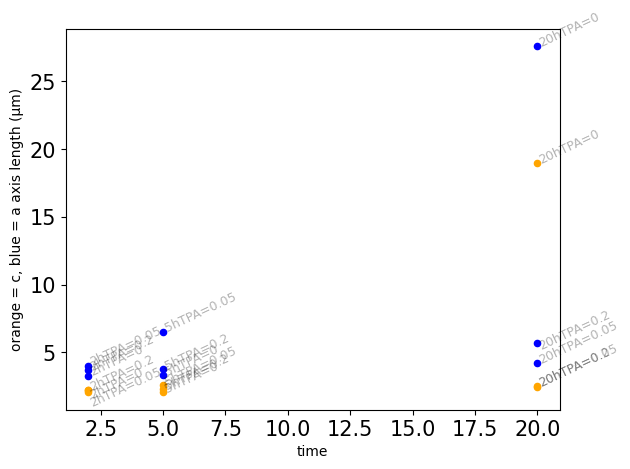

In [ ]:

scatterplot_dframe = pd.DataFrame(averages_condition)
# Display the resulting DataFrame

scatterplot_dframe = scatterplot_dframe.T
print(scatterplot_dframe)
#scatterplot_dframe.to_csv('condition_averages.csv',index=True)  
ax1 = scatterplot_dframe.plot.scatter(x='time',y='a_mean',c='blue',marker='o',alpha=1)
ax2 = scatterplot_dframe.plot.scatter(x='time',y='c_mean',c='orange',alpha=1,ylabel="orange = c, blue = a axis length (μm)", ax=ax1)

for k, v in scatterplot_dframe.iterrows():

    text = k.replace("Glass ","").replace("_","").replace(" ","")
    if text == "20hTPA=0.2":
        ax2.annotate(text,(v["time"],v["a_mean"]),alpha=0.3,fontsize=9,rotation=25,xytext=(0, -4), textcoords='offset points')
        ax2.annotate(text,(v["time"],v["c_mean"]),alpha=0.3,fontsize=9,rotation=25)
    elif text == "2hTPA=0":
        ax2.annotate(text,(v["time"],v["c_mean"]),alpha=0.3,fontsize=9,rotation=25,xytext=(0, -4), textcoords='offset points')
        ax2.annotate(text,(v["time"],v["a_mean"]),alpha=0.3,fontsize=9,rotation=25)
    elif text == "2hTPA=0.05":
        ax2.annotate(text,(v["time"],v["c_mean"]),alpha=0.3,fontsize=9,rotation=25,xytext=(0, -12), textcoords='offset points')
        ax2.annotate(text,(v["time"],v["a_mean"]),alpha=0.3,fontsize=9,rotation=25)
    else:
        ax2.annotate(text,(v["time"],v["a_mean"]),alpha=0.3,fontsize=9,rotation=25)
        ax2.annotate(text,(v["time"],v["c_mean"]),alpha=0.3,fontsize=9,rotation=25)
    
#image2_df.sort_values(by='dist_c_nm')
#plt.xlim(2,8)
#plt.yticks([1,3,5,7])
plt.xticks(rotation=0,size=15)
plt.yticks(size=15)
plt.tight_layout()
plt.savefig(f'outputs/time_scatterplot_avg_by_condition.png')
plt.show()

# Plotting with manually calculated scale (by hand)

 Plotting 2 histograms for all the images and objects in the Glass 2h TPA=0 and 5h TPA=0.05 conditions (with manually calculated scale)

In [ ]:

# Histogram of all the detections in multiple images bearing the below conditions
# Glass 2h TPA=0
# Glass 5h TPA=0.05

plot_dframe_main2 = pd.read_csv("outputs/aug2023_data_export/2_layers/dataset_median_mad1_st0.95_it0.95_l2_over0.34.csv",delimiter="|",header=0)

images1 = "Glass 2h TPA=0_"
images2 = "Glass 5h TPA=0.05"


image1_df = plot_dframe_main2[plot_dframe_main2['filename'].str.contains(images1)].copy()

image2_df = plot_dframe_main2[plot_dframe_main2['filename'].str.contains(images2)].copy()
print(len(image1_df["filename"]))
print(len(image2_df["filename"]))

coef_dict = {
    "Glass 2h TPA=0_0003": 10/200.58,
    "Glass 2h TPA=0_0005": 10/242.58,
    "Glass 2h TPA=0_0007": 20/307.2,
    "Glass 2h TPA=0_0009": 10/268.822,
    "Glass 2h TPA=0_0011": 10/216,
    "Glass 5h TPA=0.05_0003": 20/261.66,
    "Glass 5h TPA=0.05_0005": 10/231,
    "Glass 5h TPA=0.05_0007": 20/230.4,
    "Glass 5h TPA=0.05_0009": 20/231
}

for key,value in coef_dict.items():
    print(value)

935
109
0.04985541928407618
0.041223513892324176
0.06510416666666667
0.03719933636383927
0.046296296296296294
0.07643506840938621
0.04329004329004329
0.08680555555555555
0.08658008658008658


In [ ]:
image1_df.loc[:,"dist_c_nm"] = image1_df["dist_c"]
#[row_indexer,col_indexer]

image1_df.loc[:,"dist_a_nm"] = image1_df["dist_a"]
image1_df.loc[:,"area_nm"] = image1_df["area"]

image2_df.loc[:,"dist_c_nm"] = image2_df["dist_c"]
image2_df.loc[:,"dist_a_nm"] = image2_df["dist_a"]
image2_df.loc[:,"area_nm"] = image2_df["area"]

for key, value in coef_dict.items():
    if "2h" in key:
        mask = image1_df['filename'].str.contains(key)
        image1_df.loc[mask,"dist_c_nm"] *= value
        image1_df.loc[mask,"dist_a_nm"] *= value
        image1_df.loc[mask,"area_nm"] *= value
        
    if "5h" in key:
        mask = image2_df['filename'].str.contains(key)
        image2_df.loc[mask,"dist_c_nm"] *= value
        image2_df.loc[mask,"dist_a_nm"] *= value
        image2_df.loc[mask,"area_nm"] *= value


3.2552083333333335
1455    3.240741
1456    3.240741
1457    3.240741
1458    3.240741
1459    3.240741
          ...   
2385    3.290458
2386    3.190747
2387    3.290458
2388    3.390169
2389    3.190747
Name: dist_c_nm, Length: 935, dtype: float64
images Glass 2h TPA=0_ with 935 hits


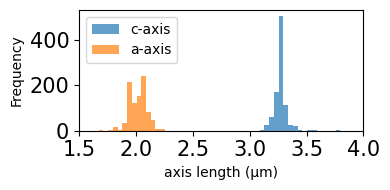

6.406926406926407
1346    4.155844
1347    5.021645
1348    5.887446
1349    6.406926
1350    5.194805
          ...   
1450    6.267676
1451    5.656195
1452    5.809065
1453    6.573416
1454    6.114805
Name: dist_c_nm, Length: 109, dtype: float64
images Glass 5h TPA=0.05 with 109 hits


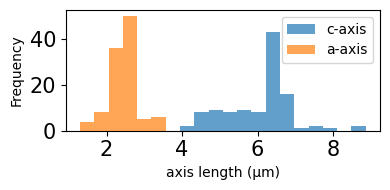

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

print(np.median(image1_df['dist_c_nm']))
print(image1_df['dist_c_nm'])

print(f"images {images1} with {len(image1_df['dist_c_nm'])} hits")
image1_df[['dist_c_nm','dist_a_nm']].plot(kind='hist',alpha=0.7,density=False,bins=100,xlabel="axis length (μm)",figsize=(4,2))
#image1_df.sort_values(by='dist_c_nm')
plt.xlim(1.5,4)
#plt.yticks([0,40,80,120])
plt.xticks(rotation=0,size=15)
plt.yticks(size=15)
plt.tight_layout()
plt.legend(["c-axis", "a-axis"])
plt.show()


print(np.median(image2_df['dist_c_nm']))
print(image2_df['dist_c_nm'])

print(f"images {images2} with {len(image2_df['dist_c_nm'])} hits")
image2_df[['dist_c_nm','dist_a_nm']].plot(kind='hist',alpha=0.7,bins=20,density=False,xlabel="axis length (μm)",figsize=(4,2))
#image2_df.sort_values(by='dist_c_nm')
#plt.xlim(2,8)
#plt.yticks([1,3,5,7])
plt.xticks(rotation=0,size=15)
plt.yticks(size=15)
plt.tight_layout()
plt.legend(["c-axis", "a-axis"])
plt.show()

## Scatter plot (all average values per condition)

In [ ]:
plot_dframe_main = pd.read_csv("outputs/aug2023_data_export/2_layers/dataset_median_mad1_st0.95_it0.95_l2_over0.34.csv",delimiter="|",header=0)


#plot_dframe_main = plot_dframe_main[~plot_dframe_main.filename.str.contains("Glass 2h TPA=0.05_0003")]
#plot_dframe_main = plot_dframe_main[~plot_dframe_main.filename.str.contains("Glass 20h TPA=0_")]

plot_dframe_copy = plot_dframe_main.copy(deep=True)

print(plot_dframe_copy)

dicting = []
for image_names in plot_dframe_main["filename"]:
    setting_name = image_names.split("/")[1].split(".tiff")[0]
    if setting_name not in dicting:
        dicting.append(setting_name)
print(dicting)

                                               filename  dist_a  dist_c   
0     outputs/Glass 5h TPA=0_0009.tiff_median_mad1_s...      34      54  \
1     outputs/Glass 5h TPA=0_0009.tiff_median_mad1_s...      34      54   
2     outputs/Glass 5h TPA=0_0009.tiff_median_mad1_s...      34      54   
3     outputs/Glass 5h TPA=0_0009.tiff_median_mad1_s...      32      54   
4     outputs/Glass 5h TPA=0_0009.tiff_median_mad1_s...      30      52   
...                                                 ...     ...     ...   
3392  outputs/Glass 20h TPA=0.05_0002.tiff_median_ma...      34      66   
3393  outputs/Glass 20h TPA=0.05_0002.tiff_median_ma...      20      56   
3394  outputs/Glass 20h TPA=0.05_0002.tiff_median_ma...      28      70   
3395  outputs/Glass 20h TPA=0.05_0002.tiff_median_ma...      32      72   
3396  outputs/Glass 20h TPA=0.05_0002.tiff_median_ma...      16      64   

      center_x  center_y  center_x_cont  center_y_cont  area  
0          695       999            

In [ ]:


# for every condition

#image1 = "outputs/|||Glass 2h TPA=0|||_0009.tiff_median_mad1_st0.95_it0.95_l2_over0.34"
#image2 = "outputs/|||Glass 5h TPA=0.05|||_0005.tiff_median_mad1_st0.95_it0.95_l2_over0.34"

# condition = Glass 5h TPA=0.05 
# axis x values = 2, 5 (h)
# axis y values = a (one column)
# axis y values = c (another column)


coef_dict = {
    "Glass 2h TPA=0_0003": 10/200.58,
    "Glass 2h TPA=0_0005": 10/242.58,
    "Glass 2h TPA=0_0007": 20/307.2,
    "Glass 2h TPA=0_0009": 10/268.822,
    "Glass 2h TPA=0_0011": 10/216,
    
    'Glass 2h TPA=0.05_0012':10/168.87,
    'Glass 2h TPA=0.05_0010':10/169.53,
    'Glass 2h TPA=0.05_0009':10/169.31,
    'Glass 2h TPA=0.05_0007':20/300.65,
    'Glass 2h TPA=0.05_0005':20/262.26,
    'Glass 2h TPA=0.05_0003':10/20.51,
    
    'Glass 2h TPA=0.2_0007': 10/203.35,
    'Glass 2h TPA=0.2_0005': 10/206.73,
    'Glass 2h TPA=0.2_0003': 20/246.11,
    
    'Glass 5h TPA=0_0009':20/323.49,
    'Glass 5h TPA=0_0007':10/235.06,
    'Glass 5h TPA=0_0005':20/314.18,
    'Glass 5h TPA=0_0003':10/215.57, 
    
    "Glass 5h TPA=0.05_0003": 20/260.95,
    "Glass 5h TPA=0.05_0005": 10/232.15,
    "Glass 5h TPA=0.05_0007": 20/230.4,
    "Glass 5h TPA=0.05_0009": 20/229.82,
    
    'Glass 5h TPA=0.2_0011':20/321.38,
    'Glass 5h TPA=0.2_0009':10/178.05,
    'Glass 5h TPA=0.2_0007':10/268.37,
    'Glass 5h TPA=0.2_0006':20/229.53,
    'Glass 5h TPA=0.2_0005':20/229.54,
    'Glass 5h TPA=0.2_0003':20/261.81,
    
    "Glass 20h TPA=0.05_0002": 30/322.04,
    "Glass 20h TPA=0.05_0003": 30/279.27,
    "Glass 20h TPA=0.05_0004": 30/230.4,
    "Glass 20h TPA=0.05_0005": 30/264.44,
    "Glass 20h TPA=0.05_0006": 10/214.69,
    "Glass 20h TPA=0.05_0007": 10/178.04,
    "Glass 20h TPA=0.05_0008": 20/238.25,
    "Glass 20h TPA=0.05_0009": 20/238.7,
    
    "Glass 20h TPA=0.2_0003": 30/292.8,
    "Glass 20h TPA=0.2_0004": 10/178.47,
    "Glass 20h TPA=0.2_0005": 20/283.64,
    "Glass 20h TPA=0.2_0006": 30/213.82,
    "Glass 20h TPA=0.2_0007": 30/246.98    
}

plot_dframe_main.loc[:,"dist_c"] = plot_dframe_copy["dist_c"].copy()
plot_dframe_main.loc[:,"dist_a"] = plot_dframe_copy["dist_a"].copy()
plot_dframe_main.loc[:,"area"] = plot_dframe_copy["area"].copy()

print(coef_dict)
for key, value in coef_dict.items():
    mask = plot_dframe_main['filename'].str.contains(key)
    plot_dframe_main.loc[mask,"dist_c"] *= value
    plot_dframe_main.loc[mask,"dist_a"] *= value
    plot_dframe_main.loc[mask,"area"] *= value
    plot_dframe_main.loc[mask,"coef"] = value

name_dict =  {}
for image_names in plot_dframe_main["filename"]:
    setting_name = image_names.split("/")[1].split("_")[0]
    setting_name += "_"

    if setting_name not in name_dict:
        name_dict[setting_name] = True

print(name_dict)
df_dict = {
    "condition_setting": [],
    "time_h": [],
    "a_nm": [],
    "c_nm": [],
    "a_pixel": [],
    "c_pixel": [],
    "coef": []
}

averages_condition = {}

for key, value in name_dict.items():
    mask = plot_dframe_main['filename'].str.contains(key)
    true_vals = sum(mask)
    setting_name_list = [key] * true_vals
    h_setting  = [int(key.split(" ")[1].replace("h",""))] * true_vals
    df_dict["condition_setting"].extend(setting_name_list)
    df_dict["time_h"].extend(h_setting)
    df_dict["a_nm"].extend(plot_dframe_main.loc[mask,"dist_c"])
    df_dict["c_nm"].extend(plot_dframe_main.loc[mask,"dist_a"])
    df_dict["a_pixel"].extend(plot_dframe_copy.loc[mask,"dist_c"])
    df_dict["c_pixel"].extend(plot_dframe_copy.loc[mask,"dist_a"])
    df_dict["coef"].extend(plot_dframe_main.loc[mask,"coef"])
    
    averages_condition[key] = {
        "time": int(key.split(" ")[1].replace("h","")),
        "a_mean": plot_dframe_main.loc[mask,"dist_c"].mean(),
        "c_mean": plot_dframe_main.loc[mask,"dist_a"].mean(),
        "a_median": plot_dframe_main.loc[mask,"dist_c"].median(),
        "c_median": plot_dframe_main.loc[mask,"dist_a"].median(),
        "a_std": plot_dframe_main.loc[mask,"dist_c"].std(),
        "c_std": plot_dframe_main.loc[mask,"dist_a"].std(),
    }
    print(max(df_dict["a_nm"]))
    print(max(df_dict["c_nm"]))
    #print(f"Mask length: {len(mask)}, vals: {true_vals}")
    #print(f"a length: {len(plot_dframe_main.loc[mask,'dist_a'])} c length: {len(plot_dframe_main.loc[mask,'dist_c'])}")
    assert true_vals == len(h_setting) == len(setting_name_list) == len(plot_dframe_main.loc[mask,"dist_c"]) == len(plot_dframe_main.loc[mask,"dist_a"])
    



{'Glass 2h TPA=0_0003': 0.04985541928407618, 'Glass 2h TPA=0_0005': 0.041223513892324176, 'Glass 2h TPA=0_0007': 0.06510416666666667, 'Glass 2h TPA=0_0009': 0.03719933636383927, 'Glass 2h TPA=0_0011': 0.046296296296296294, 'Glass 2h TPA=0.05_0012': 0.05921714928643335, 'Glass 2h TPA=0.05_0010': 0.05898661003952103, 'Glass 2h TPA=0.05_0009': 0.059063256747977085, 'Glass 2h TPA=0.05_0007': 0.06652253450856478, 'Glass 2h TPA=0.05_0005': 0.07626019980172348, 'Glass 2h TPA=0.05_0003': 0.4875670404680643, 'Glass 2h TPA=0.2_0007': 0.04917629702483403, 'Glass 2h TPA=0.2_0005': 0.04837227301310889, 'Glass 2h TPA=0.2_0003': 0.08126447523465116, 'Glass 5h TPA=0_0009': 0.06182571331416736, 'Glass 5h TPA=0_0007': 0.04254232961796988, 'Glass 5h TPA=0_0005': 0.06365777579731365, 'Glass 5h TPA=0_0003': 0.04638864405993413, 'Glass 5h TPA=0.05_0003': 0.07664303506418854, 'Glass 5h TPA=0.05_0005': 0.04307559767391773, 'Glass 5h TPA=0.05_0007': 0.08680555555555555, 'Glass 5h TPA=0.05_0009': 0.087024627969

{'Glass 5h TPA=0_': {'time': 5, 'a_mean': 3.2945048591367274, 'c_mean': 2.033808618316534, 'a_median': 3.3102043414603095, 'c_median': 2.0411003386371016, 'a_std': 0.17454953948534874, 'c_std': 0.13856624931345285}, 'Glass 5h TPA=0.2_': {'time': 5, 'a_mean': 3.8275343921510188, 'c_mean': 2.164428554642197, 'a_median': 3.819151923616961, 'c_median': 2.2465599550688005, 'a_std': 0.4356925806629108, 'c_std': 0.3118915460011363}, 'Glass 5h TPA=0.05_': {'time': 5, 'a_mean': 6.093998885350706, 'c_mean': 2.485176393806462, 'a_median': 6.423611111111111, 'c_median': 2.498384665087228, 'a_std': 0.877407628478101, 'c_std': 0.38850657354111634}, 'Glass 2h TPA=0_': {'time': 2, 'a_mean': 3.266923083660121, 'c_mean': 2.0229972840975163, 'a_median': 3.2552083333333335, 'c_median': 2.0370370370370368, 'a_std': 0.08538202499966006, 'c_std': 0.08331976574204654}, 'Glass 2h TPA=0.2_': {'time': 2, 'a_mean': 3.772287102806565, 'c_mean': 2.0926344149358993, 'a_median': 3.7381658607939534, 'c_median': 2.1283

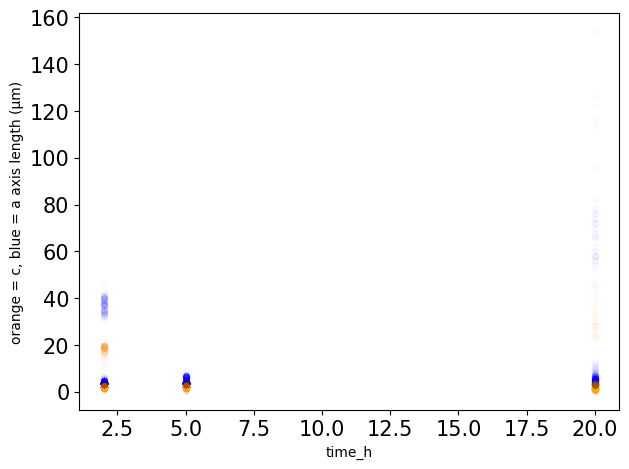

In [ ]:
global_scatterplot_dframe = pd.DataFrame(df_dict)
# Display the resulting DataFrame
print(averages_condition)
ax1 = global_scatterplot_dframe.plot.scatter(x='time_h',y=['a_nm'],c='blue',marker='o',alpha=0.01)
global_scatterplot_dframe.plot.scatter(x='time_h',y=['c_nm'],c='orange',alpha=0.01,ylabel="orange = c, blue = a axis length (μm)", ax=ax1)

#global_scatterplot_dframe.to_csv('global_values.csv',index=False)  
#image2_df.sort_values(by='dist_c_nm')
#plt.xlim(2,8)
#plt.yticks([1,3,5,7])
plt.xticks(rotation=0,size=15)
plt.yticks(size=15)
plt.tight_layout()
plt.show()

                     time     a_mean     c_mean   a_median   c_median   
Glass 5h TPA=0_       5.0   3.294505   2.033809   3.310204   2.041100  \
Glass 5h TPA=0.2_     5.0   3.827534   2.164429   3.819152   2.246560   
Glass 5h TPA=0.05_    5.0   6.093999   2.485176   6.423611   2.498385   
Glass 2h TPA=0_       2.0   3.266923   2.022997   3.255208   2.037037   
Glass 2h TPA=0.2_     2.0   3.772287   2.092634   3.738166   2.128380   
Glass 2h TPA=0.05_    2.0  12.713858   6.246586   4.270571   2.241491   
Glass 20h TPA=0_     20.0  75.000000  35.947368  70.000000  32.000000   
Glass 20h TPA=0.2_   20.0   4.846063   1.596204   4.370482   1.344764   
Glass 20h TPA=0.05_  20.0   4.924981   1.909965   4.718041   1.769994   

                         a_std      c_std  
Glass 5h TPA=0_       0.174550   0.138566  
Glass 5h TPA=0.2_     0.435693   0.311892  
Glass 5h TPA=0.05_    0.877408   0.388507  
Glass 2h TPA=0_       0.085382   0.083320  
Glass 2h TPA=0.2_     0.374349   0.264534  
Glass

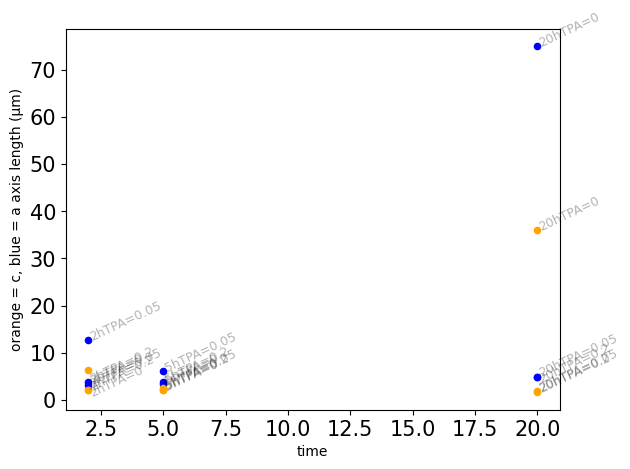

In [ ]:

scatterplot_dframe = pd.DataFrame(averages_condition)
# Display the resulting DataFrame

scatterplot_dframe = scatterplot_dframe.T
print(scatterplot_dframe)
#scatterplot_dframe.to_csv('condition_averages.csv',index=True)  
ax1 = scatterplot_dframe.plot.scatter(x='time',y='a_mean',c='blue',marker='o',alpha=1)
ax2 = scatterplot_dframe.plot.scatter(x='time',y='c_mean',c='orange',alpha=1,ylabel="orange = c, blue = a axis length (μm)", ax=ax1)

for k, v in scatterplot_dframe.iterrows():

    text = k.replace("Glass ","").replace("_","").replace(" ","")
    if text == "20hTPA=0.2":
        ax2.annotate(text,(v["time"],v["a_mean"]),alpha=0.3,fontsize=9,rotation=25,xytext=(0, -4), textcoords='offset points')
        ax2.annotate(text,(v["time"],v["c_mean"]),alpha=0.3,fontsize=9,rotation=25)
    elif text == "2hTPA=0":
        ax2.annotate(text,(v["time"],v["c_mean"]),alpha=0.3,fontsize=9,rotation=25,xytext=(0, -4), textcoords='offset points')
        ax2.annotate(text,(v["time"],v["a_mean"]),alpha=0.3,fontsize=9,rotation=25)
    elif text == "2hTPA=0.05":
        ax2.annotate(text,(v["time"],v["c_mean"]),alpha=0.3,fontsize=9,rotation=25,xytext=(0, -12), textcoords='offset points')
        ax2.annotate(text,(v["time"],v["a_mean"]),alpha=0.3,fontsize=9,rotation=25)
    else:
        ax2.annotate(text,(v["time"],v["a_mean"]),alpha=0.3,fontsize=9,rotation=25)
        ax2.annotate(text,(v["time"],v["c_mean"]),alpha=0.3,fontsize=9,rotation=25)
    
#image2_df.sort_values(by='dist_c_nm')
#plt.xlim(2,8)
#plt.yticks([1,3,5,7])
plt.xticks(rotation=0,size=15)
plt.yticks(size=15)
plt.tight_layout()
plt.show()

### Now lets compare the standard deviations of two images using either the standard deviation area filter method and circle offset filter method

In [ ]:
import pandas as pd

dataset_circ_filter_path = "outputs/varied_parameters/Glass, TPABr (2h, 5h, 20h)_0.33_point_diff_max/dataset_median_mad1_st0.95_it0.95_l1_over0.34.csv"
dataset_area_std_filter_path = "outputs/varied_parameters/Glass, TPABr (2h, 5h, 20h)_auto_scale_calc_plots_no_diff_max_filtering/dataset_median_mad1_st0.95_it0.95_l2_over0.34.csv"

dframe_circ_filter = pd.read_csv(dataset_circ_filter_path,delimiter="|",header=0)
dframe_area_filter = pd.read_csv(dataset_area_std_filter_path,delimiter="|",header=0)

image_name_sparse = "Glass 5h TPA=0.05_0003.tiff"
image_name_dense = "Glass 2h TPA=0_0007.tiff"
image_name_hard = "Glass 2h TPA=0.2_0003.tiff"
print(dframe_area_filter.head())
sparse_detections_circ_filt = dframe_circ_filter[dframe_circ_filter['filename'].str.contains(image_name_sparse)]
dense_detections_circ_filt = dframe_circ_filter[dframe_circ_filter['filename'].str.contains(image_name_dense)]
hard_detections_circ_filt = dframe_circ_filter[dframe_circ_filter['filename'].str.contains(image_name_hard)]

sparse_detections_area_std_filter = dframe_area_filter[dframe_area_filter['filename'].str.contains(image_name_sparse)]
dense_detections_area_std_filter = dframe_area_filter[dframe_area_filter['filename'].str.contains(image_name_dense)]
hard_detections_area_std_filter = dframe_area_filter[dframe_area_filter['filename'].str.contains(image_name_hard)]

print(f"---- A axis measurements: ----")
circ_filt_mean = sparse_detections_circ_filt["dist_a_nm"].mean()
area_filt_mean = sparse_detections_area_std_filter["dist_a_nm"].mean()
circ_filt_std = sparse_detections_circ_filt["dist_a_nm"].std()
area_filt_std = sparse_detections_area_std_filter["dist_a_nm"].std()
print(f"--- Sparse image ({image_name_sparse})")
print(f"Average: area std filt ({area_filt_mean}) circle filt ({circ_filt_mean})")
print(f"Standard deviation: area std filt ({area_filt_std}) circle filt ({circ_filt_std})")
len_circ_filt = len(sparse_detections_circ_filt["filename"])
len_area_filt = len(sparse_detections_area_std_filter["filename"])
print(f"Counts of crystals detected: area std filt ({len_area_filt}) circle filt ({len_circ_filt})")

circ_filt_mean = dense_detections_circ_filt["dist_a_nm"].mean()
area_filt_mean = dense_detections_area_std_filter["dist_a_nm"].mean()
circ_filt_std = dense_detections_circ_filt["dist_a_nm"].std()
area_filt_std = dense_detections_area_std_filter["dist_a_nm"].std()
print(f"--- Dense image ({image_name_dense})")
print(f"Average: area std filt ({area_filt_mean}) circle filt ({circ_filt_mean})")
print(f"Standard deviation: area std filt ({area_filt_std}) circle filt ({circ_filt_std})")
len_circ_filt = len(dense_detections_circ_filt["filename"])
len_area_filt = len(dense_detections_area_std_filter["filename"])
print(f"Counts of crystals detected: area std filt ({len_area_filt}) circle filt ({len_circ_filt})")


circ_filt_mean = hard_detections_circ_filt["dist_a_nm"].mean()
area_filt_mean = hard_detections_area_std_filter["dist_a_nm"].mean()
circ_filt_std = hard_detections_circ_filt["dist_a_nm"].std()
area_filt_std = hard_detections_area_std_filter["dist_a_nm"].std()
print(f"--- Hard image ({image_name_hard})")
print(f"Average: area std filt ({area_filt_mean}) circle filt ({circ_filt_mean})")
print(f"Standard deviation: area std filt ({area_filt_std}) circle filt ({circ_filt_std})")
len_circ_filt = len(hard_detections_circ_filt["filename"])
len_area_filt = len(hard_detections_area_std_filter["filename"])
print(f"Counts of crystals detected: area std filt ({len_area_filt}) circle filt ({len_circ_filt})")



print(f"\n---- C axis measurements: ----")
circ_filt_mean = sparse_detections_circ_filt["dist_c_nm"].mean()
area_filt_mean = sparse_detections_area_std_filter["dist_c_nm"].mean()
circ_filt_std = sparse_detections_circ_filt["dist_c_nm"].std()
area_filt_std = sparse_detections_area_std_filter["dist_c_nm"].std()
print(f"--- Sparse image ({image_name_sparse})")
print(f"Average: area std filt ({area_filt_mean}) circle filt ({circ_filt_mean})")
print(f"Standard deviation: area std filt ({area_filt_std}) circle filt ({circ_filt_std})")
len_circ_filt = len(sparse_detections_circ_filt["filename"])
len_area_filt = len(sparse_detections_area_std_filter["filename"])
print(f"Counts of crystals detected: area std filt ({len_area_filt}) circle filt ({len_circ_filt})")


circ_filt_mean = dense_detections_circ_filt["dist_c_nm"].mean()
area_filt_mean = dense_detections_area_std_filter["dist_c_nm"].mean()
circ_filt_std = dense_detections_circ_filt["dist_c_nm"].std()
area_filt_std = dense_detections_area_std_filter["dist_c_nm"].std()
print(f"--- Dense image ({image_name_dense})")
print(f"Average: area std filt ({area_filt_mean}) circle filt ({circ_filt_mean})")
print(f"Standard deviation: area std filt ({area_filt_std}) circle filt ({circ_filt_std})")
len_circ_filt = len(dense_detections_circ_filt["filename"])
len_area_filt = len(dense_detections_area_std_filter["filename"])
print(f"Counts of crystals detected: area std filt ({len_area_filt}) circle filt ({len_circ_filt})")

circ_filt_mean = hard_detections_circ_filt["dist_c_nm"].mean()
area_filt_mean = hard_detections_area_std_filter["dist_c_nm"].mean()
circ_filt_std = hard_detections_circ_filt["dist_c_nm"].std()
area_filt_std = hard_detections_area_std_filter["dist_c_nm"].std()
print(f"--- Hard image ({image_name_hard})")
print(f"Average: area std filt ({area_filt_mean}) circle filt ({circ_filt_mean})")
print(f"Standard deviation: area std filt ({area_filt_std}) circle filt ({circ_filt_std})")
len_circ_filt = len(hard_detections_circ_filt["filename"])
len_area_filt = len(hard_detections_area_std_filter["filename"])
print(f"Counts of crystals detected: area std filt ({len_area_filt}) circle filt ({len_circ_filt})")




                                            filename  dist_a_nm  dist_c_nm   
0  outputs/Glass 5h TPA=0_0009.tiff_median_mad1_s...   2.111801   3.354037  \
1  outputs/Glass 5h TPA=0_0009.tiff_median_mad1_s...   2.111801   3.354037   
2  outputs/Glass 5h TPA=0_0009.tiff_median_mad1_s...   2.111801   3.354037   
3  outputs/Glass 5h TPA=0_0009.tiff_median_mad1_s...   1.987578   3.354037   
4  outputs/Glass 5h TPA=0_0009.tiff_median_mad1_s...   1.863354   3.229814   

   dist_a_pix  dist_c_pix  center_x_outer  center_y_outer  center_x_inner   
0          34          54             695             999             695  \
1          34          54             822             816             821   
2          34          54             921             830             921   
3          32          54             738             985             738   
4          30          52             779             922             779   

   center_y_inner  area_pix  scale_pixel_in_nms  scale_nm_in_pixels 